Deep Learning Task 1

Written By: Karin Fridkin and Rotem ----

Description: building a simple neural network “from scratch”.

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from dnn_model import l_layer_model, predict

In [2]:
def load_and_preprocess_mnist(number_of_classes = 10):
    # Load
    (x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.mnist.load_data(path='mnist.npz')
    
    # Flatten: (60000, 28, 28) -> (784, 60000) and normalize to [0, 1]
    x_train_full = x_train_full.reshape(-1, 784).T / 255.0
    x_test       = x_test.reshape(-1, 784).T       / 255.0
    
    # One-hot encode labels: (60000,) -> (10, 60000)
    y_train_full = np.eye(number_of_classes)[y_train_full].T
    y_test       = np.eye(number_of_classes)[y_test].T
    
    # Split train -> train (80%) + validation (20%)
    m             = x_train_full.shape[1]
    m_val         = int(m * 0.2)
    
    np.random.seed(42)
    permutation   = np.random.permutation(m)
    train_idx     = permutation[m_val:]
    val_idx       = permutation[:m_val]
    
    x_train, y_train = x_train_full[:, train_idx], y_train_full[:, train_idx]
    x_val,   y_val   = x_train_full[:, val_idx],   y_train_full[:, val_idx]
    
    # Summary
    print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
    
    return x_train, y_train, x_val, y_val, x_test, y_test

In [3]:
x_train, y_train, x_val, y_val, x_test, y_test = load_and_preprocess_mnist()

Train: (784, 48000) | Val: (784, 12000) | Test: (784, 10000)


In [4]:
LAYER_DIMS    = [784, 20, 7, 5, 10]
LEARNING_RATE = 0.009
BATCH_SIZE    = 512
NUM_ITERATIONS = 1000 

parameters, costs = l_layer_model(
    x_train, y_train,
    layers_dims    = LAYER_DIMS,
    learning_rate  = LEARNING_RATE,
    num_iterations = NUM_ITERATIONS,
    batch_size     = BATCH_SIZE,
    use_batchnorm  = False,
    X_val          = x_val,
    Y_val          = y_val
)

Iteration 100 | Train Cost: 1.938374 | Val Cost: 1.943917
Iteration 200 | Train Cost: 1.772671 | Val Cost: 1.778619
Iteration 300 | Train Cost: 1.676960 | Val Cost: 1.682073
Iteration 400 | Train Cost: 1.604905 | Val Cost: 1.608717
Iteration 500 | Train Cost: 1.539283 | Val Cost: 1.542075
Iteration 600 | Train Cost: 1.473078 | Val Cost: 1.474182
Iteration 700 | Train Cost: 1.406857 | Val Cost: 1.406153
Iteration 800 | Train Cost: 1.339614 | Val Cost: 1.337508
Iteration 900 | Train Cost: 1.273200 | Val Cost: 1.269717
Iteration 1000 | Train Cost: 1.210733 | Val Cost: 1.205924
Iteration 1100 | Train Cost: 1.151971 | Val Cost: 1.146111
Iteration 1200 | Train Cost: 1.097312 | Val Cost: 1.090536
Iteration 1300 | Train Cost: 1.045580 | Val Cost: 1.038559
Iteration 1400 | Train Cost: 0.995188 | Val Cost: 0.988128
Iteration 1500 | Train Cost: 0.949184 | Val Cost: 0.941859
Iteration 1600 | Train Cost: 0.906013 | Val Cost: 0.899185
Iteration 1700 | Train Cost: 0.868868 | Val Cost: 0.861662
Iterat

In [5]:
train_accuracy = predict(x_train, y_train, parameters)
val_accuracy   = predict(x_val,   y_val,   parameters)
test_accuracy  = predict(x_test,  y_test,  parameters)

print(f" train accuracy:     {train_accuracy * 100:.2f}%")
print(f" validation accuracy:  {val_accuracy * 100:.2f}%")
print(f" test accuracy:       {test_accuracy * 100:.2f}%")

 train accuracy:     93.31%
 validation accuracy:  92.56%
 test accuracy:       92.58%


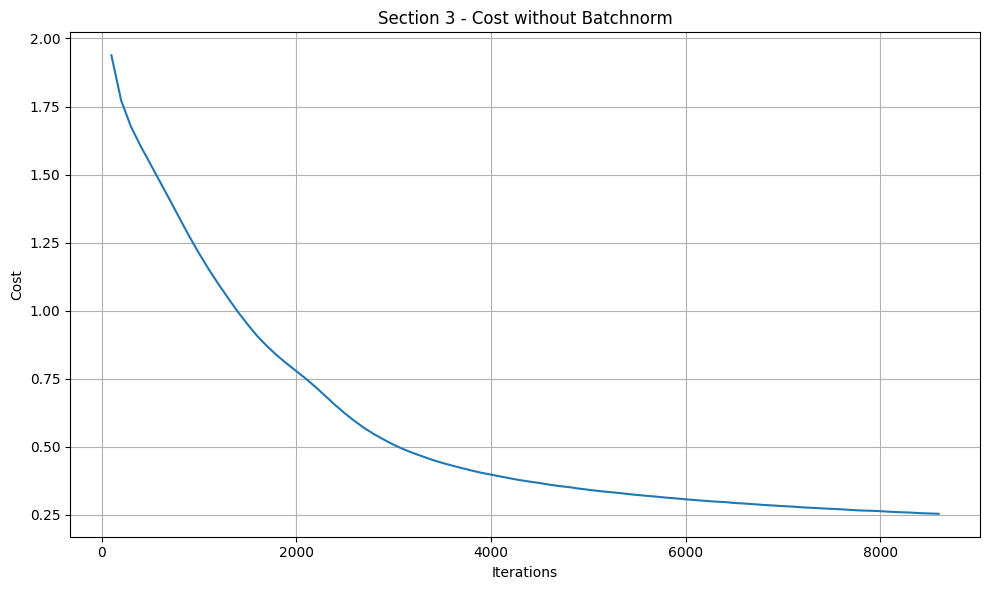

In [6]:
def plot_costs(costs, learning_rate, title="Cost over Training"):
    plt.figure(figsize=(10, 6))
    
    iterations = [i * 100 for i in range(1, len(costs) + 1)]
    
    plt.plot(iterations, costs)
    plt.xlabel("Iterations")
    plt.ylabel("Cost")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_costs(costs, learning_rate=0.009, title="Section 3 - Cost without Batchnorm")

In [31]:
# Batch Normalization Backpropagation (znormi):
# We calculate the gradient of the cost with respect to Z by considering 
# the influence of each Zi on the batch mean and variance. 
# This ensures the chain rule is preserved through the normalization step.

LAYER_DIMS    = [784, 20, 7, 5, 10]
LEARNING_RATE = 0.009
BATCH_SIZE    = 512
NUM_ITERATIONS = 1000 

parameters_bn, costs_bn = l_layer_model(
    x_train, y_train,
    layers_dims    = LAYER_DIMS,
    learning_rate  = LEARNING_RATE,
    num_iterations = NUM_ITERATIONS,
    batch_size     = BATCH_SIZE,
    use_batchnorm  = True,
    X_val          = x_val,
    Y_val          = y_val
)

Iteration 100 | Train Cost: 1.859572 | Val Cost: 1.864058
Iteration 200 | Train Cost: 1.713019 | Val Cost: 1.716478
Iteration 300 | Train Cost: 1.646548 | Val Cost: 1.649480
Iteration 400 | Train Cost: 1.603570 | Val Cost: 1.606172
Iteration 500 | Train Cost: 1.570697 | Val Cost: 1.573199
Iteration 600 | Train Cost: 1.543190 | Val Cost: 1.545301
Iteration 700 | Train Cost: 1.518649 | Val Cost: 1.520780
Iteration 800 | Train Cost: 1.495772 | Val Cost: 1.497967
Iteration 900 | Train Cost: 1.473901 | Val Cost: 1.476105
Iteration 1000 | Train Cost: 1.452215 | Val Cost: 1.454336
Iteration 1100 | Train Cost: 1.431119 | Val Cost: 1.433058
Iteration 1200 | Train Cost: 1.409817 | Val Cost: 1.411574
Iteration 1300 | Train Cost: 1.388026 | Val Cost: 1.389875
Iteration 1400 | Train Cost: 1.366069 | Val Cost: 1.368013
Iteration 1500 | Train Cost: 1.343813 | Val Cost: 1.345853
Iteration 1600 | Train Cost: 1.321666 | Val Cost: 1.323942
Iteration 1700 | Train Cost: 1.299879 | Val Cost: 1.302345
Iterat

In [32]:
train_accuracy_bn = predict(x_train, y_train, parameters_bn,True)
val_accuracy_bn   = predict(x_val,   y_val,   parameters_bn,True)
test_accuracy_bn  = predict(x_test,  y_test,  parameters_bn,True)

print(f"Train Accuracy:      {train_accuracy_bn * 100:.2f}%")
print(f"Validation Accuracy: {val_accuracy_bn * 100:.2f}%")
print(f"Test Accuracy:       {test_accuracy_bn * 100:.2f}%")

Train Accuracy:      93.67%
Validation Accuracy: 92.23%
Test Accuracy:       92.20%


In [27]:
#l2 norm
#printing the w before l2 and after

LAMBD = 0.1

parameters_l2, costs_l2 = l_layer_model(
    x_train, y_train, 
    layers_dims    = [784, 20, 7, 10], 
    learning_rate  = 0.009, 
    num_iterations = 3000, 
    batch_size     = 512, 
    use_batchnorm  = True, 
    X_val          = x_val, 
    Y_val          = y_val,
    lambd          = LAMBD  
)

Iteration 100 | Train Cost: 1.901247 | Val Cost: 1.914331
Iteration 200 | Train Cost: 1.573976 | Val Cost: 1.586157
Iteration 300 | Train Cost: 1.418622 | Val Cost: 1.428674
Iteration 400 | Train Cost: 1.322055 | Val Cost: 1.330778
Iteration 500 | Train Cost: 1.253065 | Val Cost: 1.261026
Iteration 600 | Train Cost: 1.198695 | Val Cost: 1.205962
Iteration 700 | Train Cost: 1.154016 | Val Cost: 1.160762
Iteration 800 | Train Cost: 1.115949 | Val Cost: 1.121776
Iteration 900 | Train Cost: 1.083147 | Val Cost: 1.088394
Iteration 1000 | Train Cost: 1.055056 | Val Cost: 1.060147
Iteration 1100 | Train Cost: 1.029241 | Val Cost: 1.034357
Iteration 1200 | Train Cost: 1.006056 | Val Cost: 1.011404
Iteration 1300 | Train Cost: 0.986182 | Val Cost: 0.991872
Iteration 1400 | Train Cost: 0.967298 | Val Cost: 0.972972
Iteration 1500 | Train Cost: 0.950579 | Val Cost: 0.956402
Iteration 1600 | Train Cost: 0.934971 | Val Cost: 0.940916
Iteration 1700 | Train Cost: 0.920816 | Val Cost: 0.926667
Iterat

In [28]:
train_accuracy_l2 = predict(x_train, y_train, parameters_l2, use_batchnorm=True)
val_accuracy_l2   = predict(x_val,   y_val,   parameters_l2, use_batchnorm=True)
test_accuracy_l2  = predict(x_test,  y_test,  parameters_l2, use_batchnorm=True)

print("--- L2 Regularization Results ---")
print(f"Train Accuracy:      {train_accuracy_l2 * 100:.2f}%")
print(f"Validation Accuracy: {val_accuracy_l2 * 100:.2f}%")
print(f"Test Accuracy:       {test_accuracy_l2 * 100:.2f}%")

--- L2 Regularization Results ---
Train Accuracy:      90.48%
Validation Accuracy: 90.03%
Test Accuracy:       90.70%


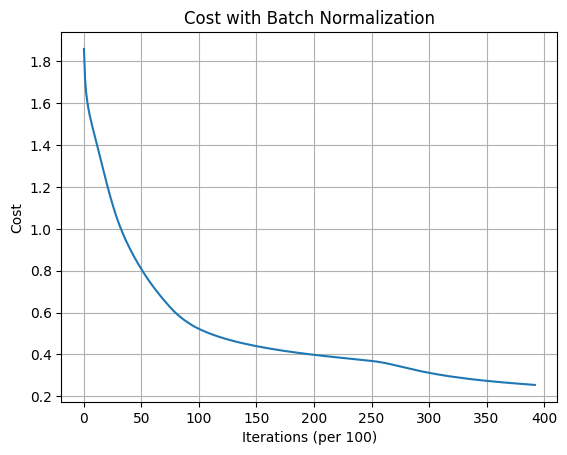

In [29]:
def plot_costs(costs, title="Model Convergence"):
    plt.plot(costs)
    plt.ylabel('Cost')
    plt.xlabel('Iterations (per 100)')
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_costs(costs_bn, title="Cost with Batch Normalization")

In [30]:
def compare_weights(params_no_l2, params_l2):
    print("Layer | Avg Weight (No L2) | Avg Weight (With L2)")
    print("-" * 45)
    for l in range(1, len(params_no_l2)//2):
        w_no_l2 = np.mean(np.abs(params_no_l2[f"W{l}"]))
        w_l2    = np.mean(np.abs(params_l2[f"W{l}"]))
        print(f"  {l}   |      {w_no_l2:.6f}      |      {w_l2:.6f}")

compare_weights(parameters_bn, parameters_l2)

Layer | Avg Weight (No L2) | Avg Weight (With L2)
---------------------------------------------
  1   |      0.040133      |      0.039034
  2   |      0.246930      |      0.226303
  3   |      0.559495      |      0.468558
